## Notebook fait en APP avec les codes de Catz au propre 

In [30]:
##--------------------------------------------------------### 
                # Importation des librairies
##--------------------------------------------------------###

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import validation_curve
from sklearn.linear_model import Perceptron

##--------------------------------------------------------###
    # Configuration de l'ethétique des figures
##--------------------------------------------------------###

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False #Bordure haut désactivé
plt.rcParams['axes.spines.right'] = False #Bordure droit désactivé
plt.rcParams['axes.spines.left'] = True #Bordure gauche activé
plt.rcParams['axes.spines.bottom'] = True #Bordure bas activé
plt.rcParams['axes.grid'] = False #Grille désactivé
plt.rcParams['legend.frameon'] = False #Légende sans cadre
plt.rcParams['legend.loc'] = 'best' #Position de la légende (best pour la meilleure position automatique)

plt.rcParams['legend.fontsize'] = 11
plt.rcParams['legend.title_fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 9  # Taille des labels des xticks
plt.rcParams['ytick.labelsize'] = 9  # Taille des labels des yticks
plt.rcParams['legend.fontsize'] = 9 # Taille des labels de la légende
plt.rcParams['figure.titlesize'] = 15  # Taille du titre de la figure
plt.rcParams['axes.titlesize'] = 13  # Taille du titre des sous-graphes
plt.rcParams['axes.labelsize'] = 11  # Taille des labels des axes

##--------------------------------------------------------###
                #Chemin
##--------------------------------------------------------###
   
path="/media/nicolascatz/ssdcalcul/Projets/M1_NEURO_APP_NC"
path="C:/Python/M1_NEURO_APP_NC"

pathresults=path+"/out/"
pathscripts=path+"/scripts/"

file=np.load(pathresults+"FileAll.npz", allow_pickle=True)["arr_0"]
unit=np.load(pathresults+"UnitAll.npz", allow_pickle=True)["arr_0"]

### Structure Données `unit[0]`

Définition de la matrice d'activité pour le neurone 0.

**Décomposition du code**  
- `unit[0]` : Matrice d'activité du **premier neurone** (indice 0)

**Structure des données**  
- **Lignes** : Essais (chaque ligne = 1 essai)  
- **Colonnes** : 301 colonnes  
  - Colonne 0 : condition stimulus (D1=1, D2=2, D3=3, D4=4)  
  - Colonnes 1:300 : bins temporels (spikes = 1, silence = 0)  

Matrice **(N_essais × 301)** contenant l'activité complète du neurone 0 pour tous les essais.

-> Base pour extraire `stim = unit[0][:,0]` et `unitex = unit[0][:,1:]`.

In [4]:
unit[0]  #Matrix qui fait 301 colone et les lignes sont les essais 

array([[2, 0, 0, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 0],
       ...,
       [4, 0, 0, ..., 0, 0, 0],
       [4, 0, 0, ..., 0, 0, 0],
       [4, 0, 0, ..., 0, 0, 0]], shape=(950, 301))

### Figure 2 Panneaux : Raster + PSTH Neurone 4

Visualiser l'activité du neurone 4 sous forme de **raster plot** et **PSTH** (tous essais confondus).

**Décomposition du code**  

**Panneau 1 - Raster plot (gauche)**  
- `ax[0].spy(unit[4][:,1:], aspect='auto', markersize=0.5)` : **Points = spikes** pour tous les essais (sauf colonne condition)  
- `ax[0].axvline(x=100, color='r', linestyle='--')` : **Ligne stimulus** à 100 bins (t=0ms)  
- `ax[0].xaxis.tick_bottom()` : Labels X en bas  

**Panneau 2 - PSTH (droite)**  
- `ax[1].plot(unit[4][:,1:].mean(axis=0))` : **Moyenne tous essais** → taux de décharge temporel  
- `ax[1].axvline(x=100, color='r', linestyle='--')` : **Ligne stimulus** alignée  

**Résultat**  
- **Gauche** : Variabilité essai par essai  
- **Droite** : Profil de réponse moyen du neurone  

Text(0, 0.5, 'Essais')

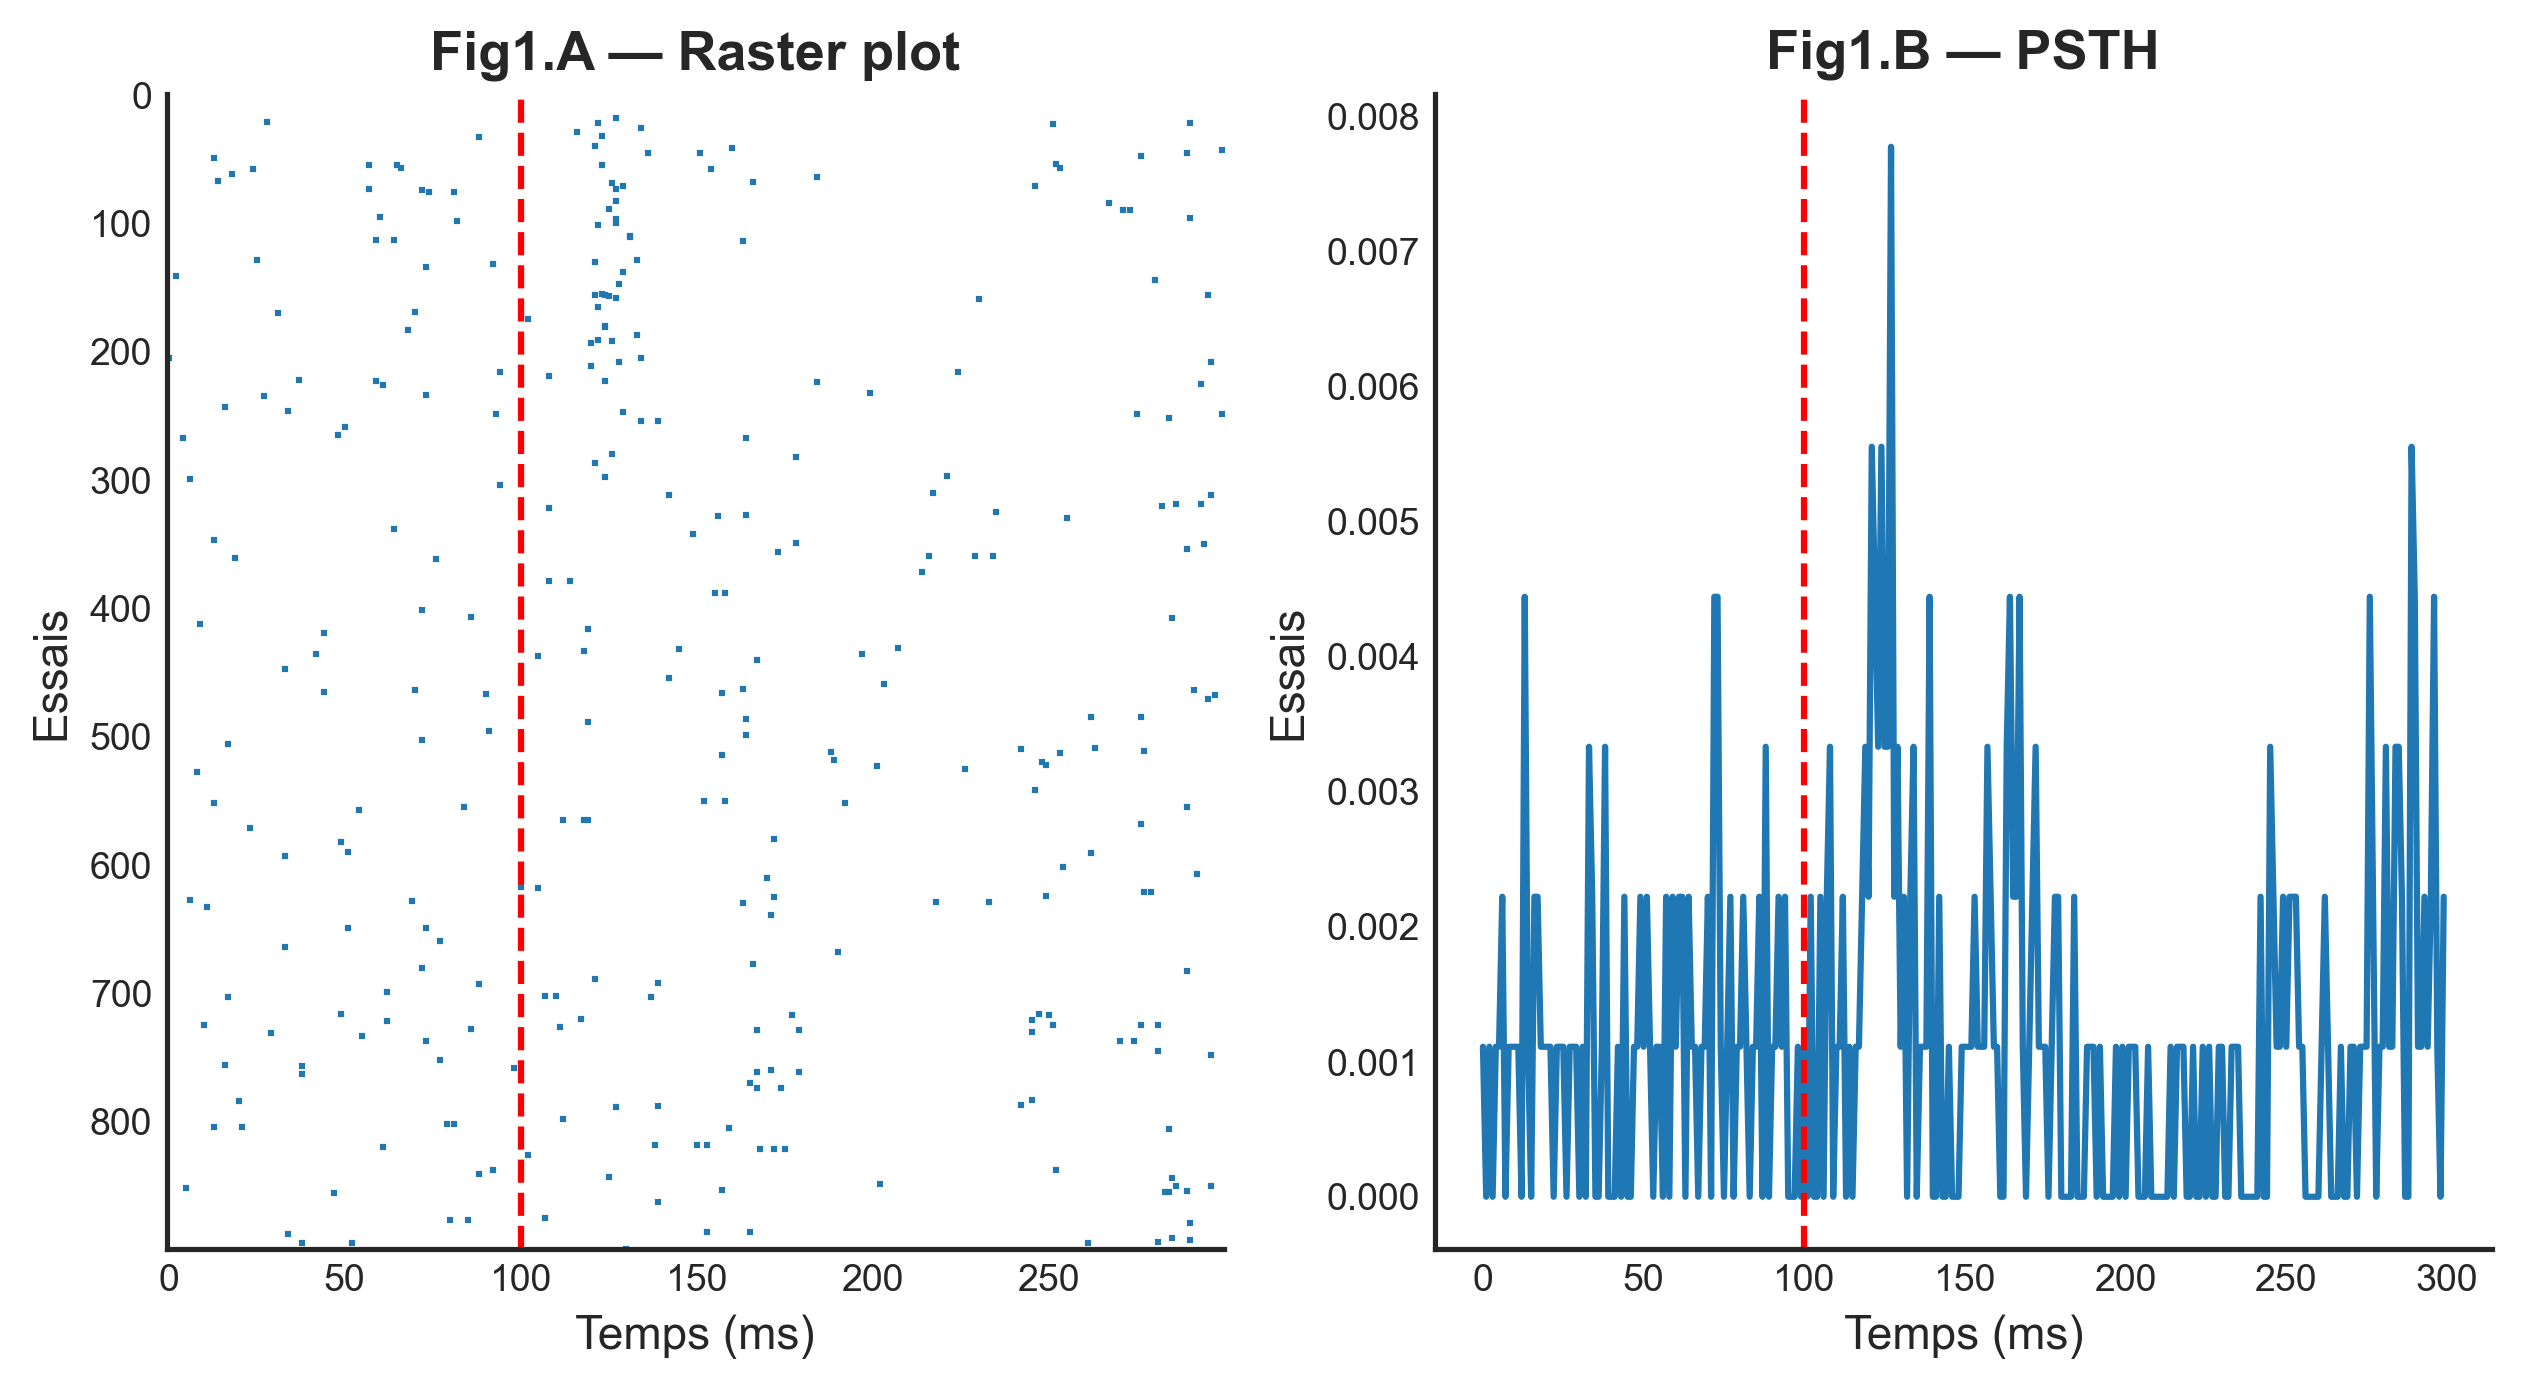

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
                       
ax[0].spy(unit[4][:,1:], aspect='auto', markersize=0.5) # tout les essais sauf la colonne 0 qui est expérimental #aspect auto et markersize pour ajuster la taille des points
ax[0].axvline(x=100, color='r', linestyle='--') # ligne verticale à 1000 ms (h pour horrizontal)
ax[0].xaxis.tick_bottom()
ax[0].set_title('Fig1.A — Raster plot', fontweight='bold')
ax[0].set_xlabel('Temps (ms)')
ax[0].set_ylabel('Essais')

ax[1].plot(unit[4][:,1:].mean(axis=0)) #moyenne de tous les essais pour chaque 
ax[1].axvline(x=100, color='r', linestyle='--')
ax[1].set_title('Fig1.B — PSTH', fontweight='bold')
ax[1].set_xlabel('Temps (ms)')
ax[1].set_ylabel('Essais')

### Bloc Complet : Préparation Données Neurone 4

**Objectif**  
Préparer les données du neurone 4 et vérifier l'équilibrage des conditions.

**Décomposition du code**  
- `stim=unit[4][:,0]` : Extrait le **vecteur des conditions** (D1=1, D2=2, D3=3, D4=4)  
- `unitex=unit[4][:,1:]` : Extrait la **matrice d'activité** (essais × bins temps)  
- `unit[4][:,0].tolist().count(2)` : **Compte les essais D2** (condition = 2)  

**Méthode `.count()` et `.index()`**  
- `.count(2)` : Compte **combien de fois** la condition D2 apparaît dans la séquence  
- `.tolist()` : Convertit **numpy array → liste Python** (nécessaire pour `.count()`)  
- Autres conditions : `.count(3)` (D3), `.count(4)` (D4) **(pas de D1=1 ni D5)**  
- `.index(4)` : Trouve la **position du 1er essai D4** (ex: essai #600)  

**Résultat**  
- `stim` : vecteur conditions (N_essais,)  
- `unitex` : matrice spikes (N_essais × 300 bins)  
- Entiers : **nombres d'essais par condition D2/D3/D4**  
- Position : **1er essai D4** (ex: 600)  

**Utilité**  
- Vérification **équilibrage expérimental** (25 D2, 25 D3, 25 D4 ?)  
- Localisation précise des essais par condition pour analyses ciblées

In [ ]:
stim=unit[4][:,0]
unitex=unit[4][:,1:]

unit[4][:,0].tolist().count(2)

300

### Figure 1 — Analyse d’un neurone

Cette figure présente l’activité du neurone `n = 100` à l’aide de quatre visualisations complémentaires.

- **Fig1.A — Raster plot** : représentation des spikes pour tous les essais entre -50 et +100 ms autour du stimulus.
- **Fig1.B — PSTH** : moyenne de l’activité par condition (`D2`, `D3`, `D4`) afin de comparer les profils de réponse.
- **Fig1.C — Boxplot** : distribution de l’activité moyenne par condition.
- **Fig1.D — Histogramme** : distribution des firing rates dans la fenêtre 10-40 ms après le stimulus.

Le stimulus est aligné à `t = 0 ms`, correspondant ici à la position `x = 50` dans les données.

```python
n = 100
stim = unit[n][:, 0]
unitex = unit[n][:, 50:200]
mean_unit = unit[n][:, 100:150].mean(axis=1)
```

- `stim` contient la condition associée à chaque essai.
- `unitex` correspond à la fenêtre temporelle utilisée pour l’analyse générale.
- `mean_unit` correspond à l’activité moyenne dans la fenêtre 10-40 ms post-stimulus.

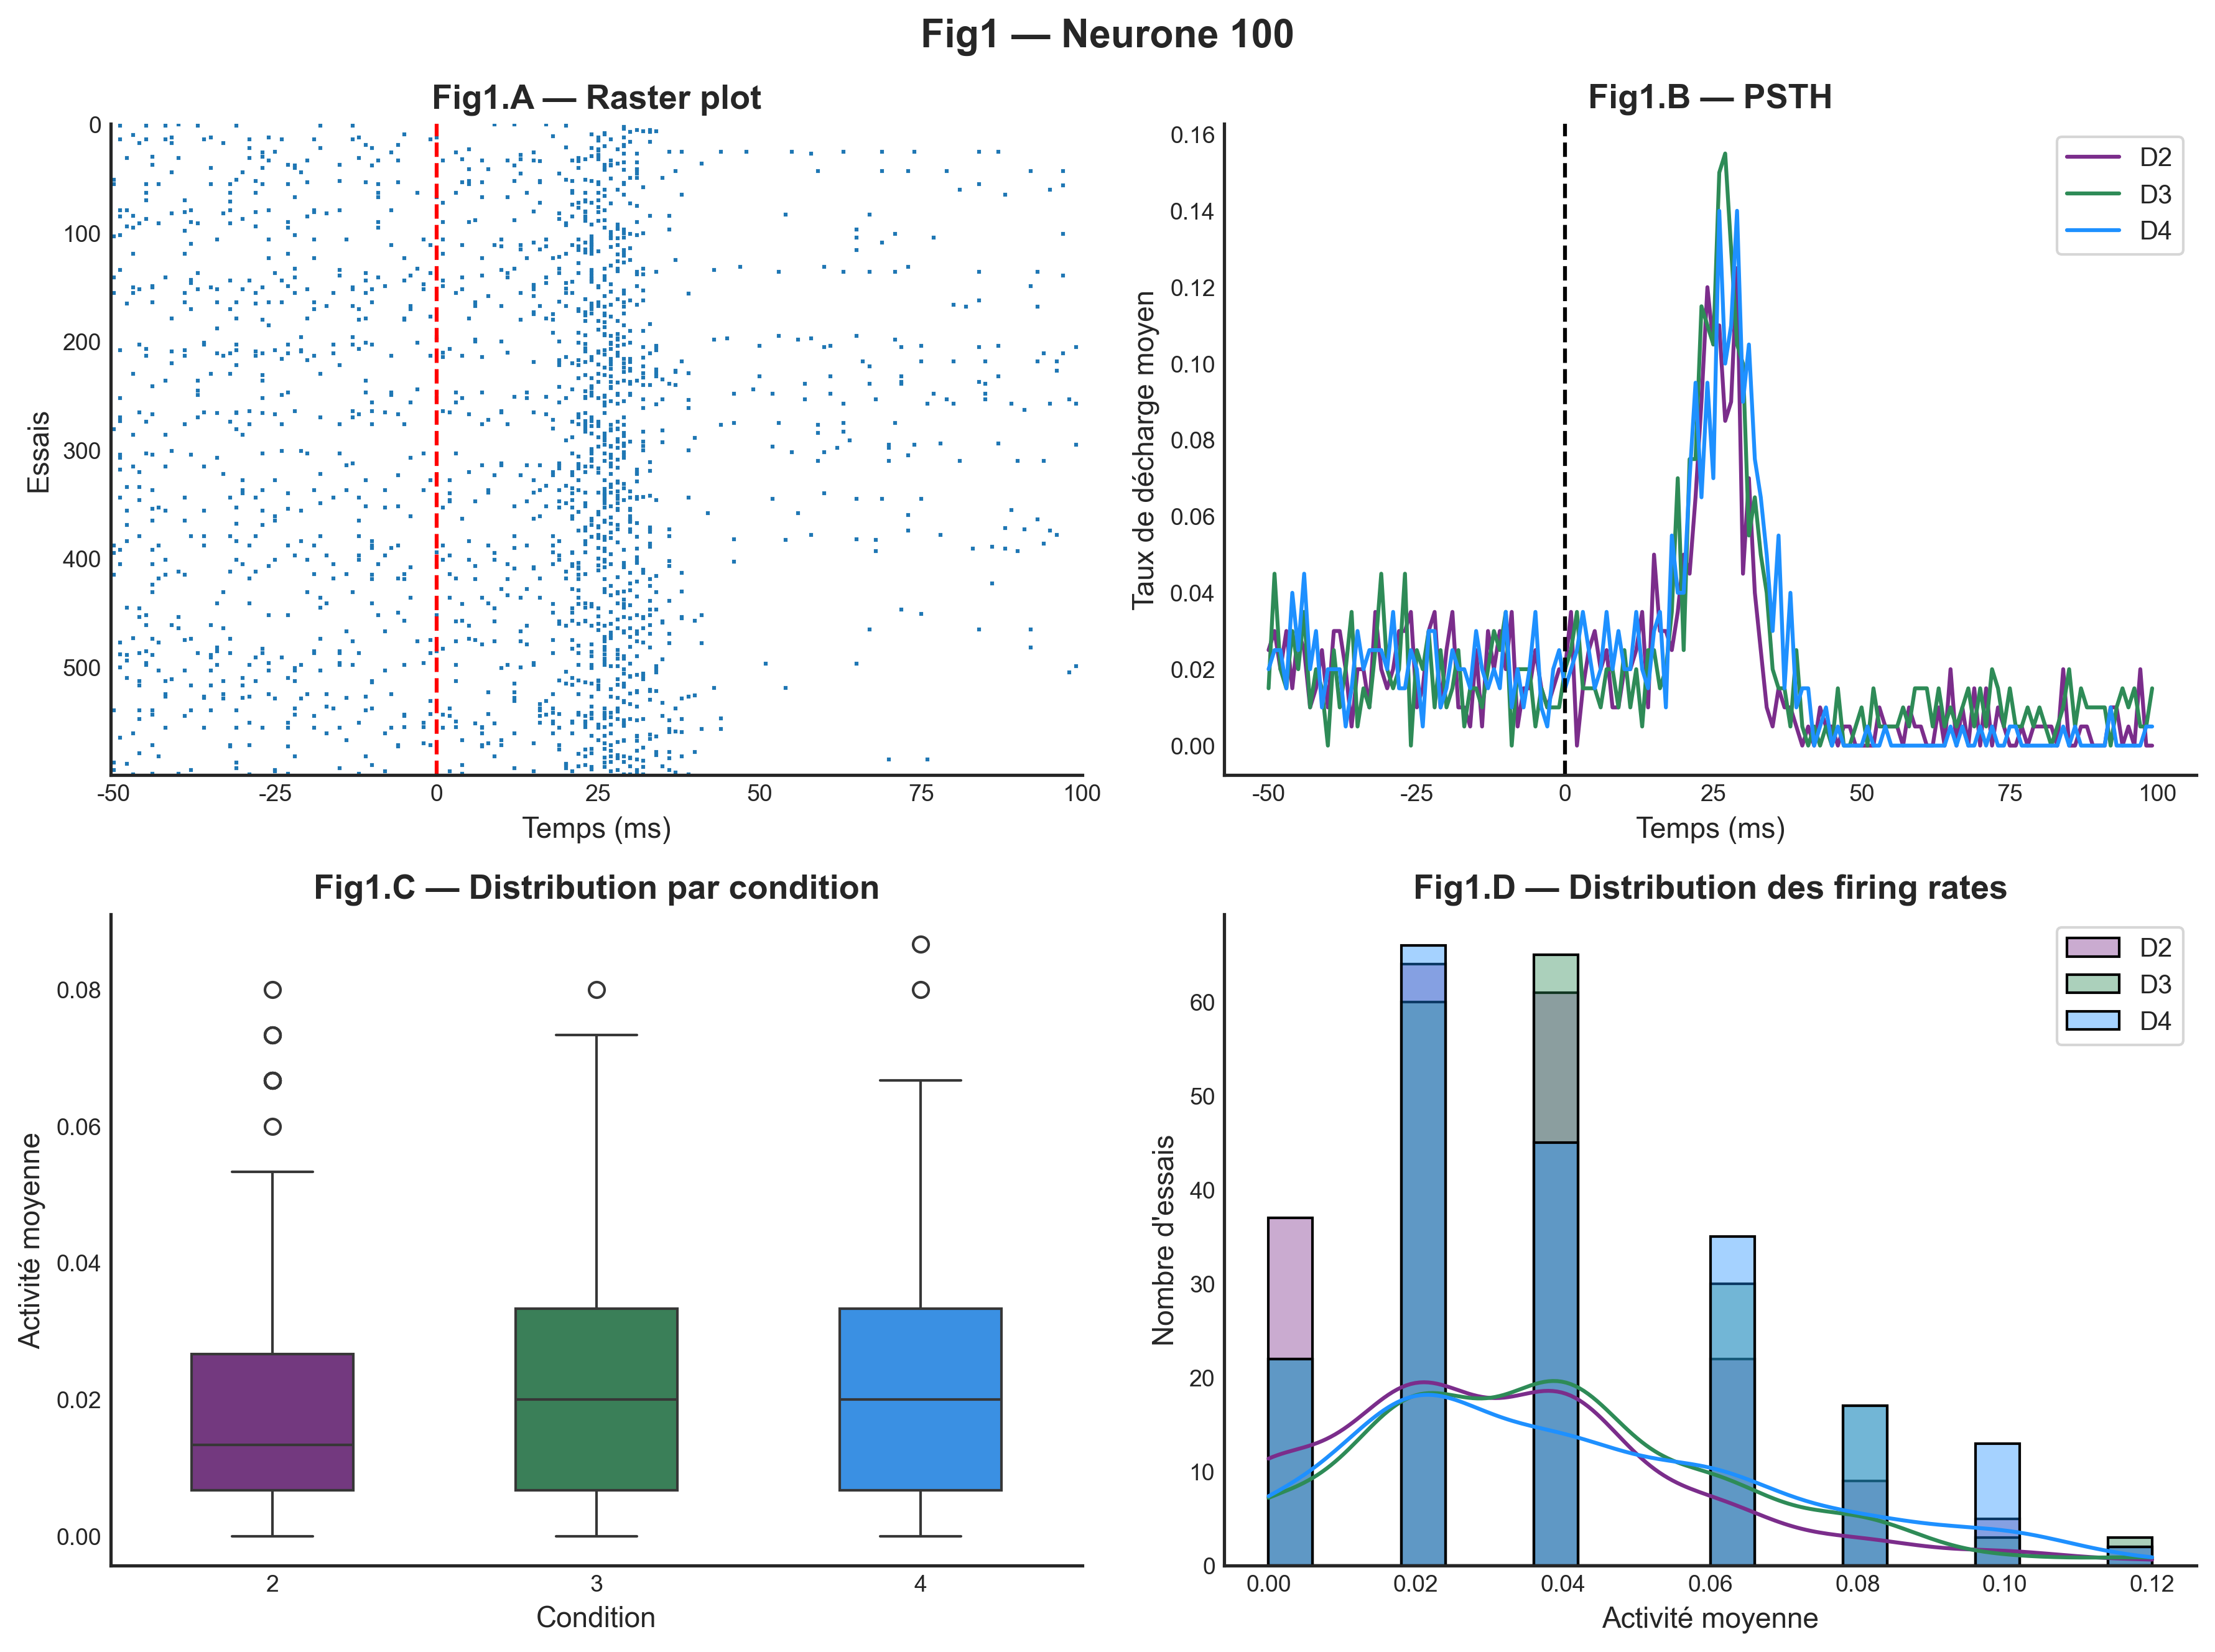

In [ ]:
n = 100
stim = unit[n][:, 0]
unitex = unit[n][:, 50:200]
mean_unit = unit[n][:, 100:150].mean(axis=1)
COLORS = ['#7B2D8B', '#2E8B57', '#1E90FF', '#FFD700']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
fig.suptitle(f"Fig1 — Neurone {n}", fontweight='bold')
ax_flat = ax.flatten()

# --- Fig1.A — Raster plot ---
ax_flat[0].spy(unit[n][:, 50:200], aspect='auto', markersize=0.5)
ax_flat[0].axvline(x=50, color='r', linestyle='--')
ax_flat[0].set_xticks([0, 25, 50, 75, 100, 125, 150])
ax_flat[0].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])
ax_flat[0].xaxis.tick_bottom()
ax_flat[0].set_title('Fig1.A — Raster plot', fontweight='bold')
ax_flat[0].set_xlabel('Temps (ms)')
ax_flat[0].set_ylabel('Essais')

# --- Fig1.B — PSTH ---
for i, (cond, label) in enumerate(zip([2, 3, 4], ['D2', 'D3', 'D4'])):
    ax_flat[1].plot(unit[n][unit[n][:,0] == cond][:, 50:200].mean(axis=0), label=label, color=COLORS[i])

ax_flat[1].axvline(x=50, color='k', linestyle='--')
ax_flat[1].set_xticks([0, 25, 50, 75, 100, 125, 150])
ax_flat[1].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])
ax_flat[1].legend(frameon=True, loc='upper right', fontsize= 10)
ax_flat[1].set_title('Fig1.B — PSTH', fontweight='bold')
ax_flat[1].set_xlabel('Temps (ms)')
ax_flat[1].set_ylabel('Taux de décharge moyen')

# --- Fig1.C — Boxplot ---
sns.boxplot(x=stim, y=unitex.mean(axis=1), ax=ax_flat[2], palette=COLORS[:4], width=0.5)
ax_flat[2].set_title('Fig1.C — Distribution par condition', fontweight='bold')
ax_flat[2].set_xlabel('Condition')
ax_flat[2].set_ylabel('Activité moyenne')

# --- Fig1.D — Histplot ---
for i, (cond, label) in enumerate(zip([2, 3, 4], ['D2', 'D3', 'D4'])):
    sns.histplot(mean_unit[unit[n][:,0] == cond], bins=20, label=label, kde=True, ax=ax_flat[3], color=COLORS[i], alpha=0.4)

ax_flat[3].legend(frameon=True, loc='upper right', fontsize= 10)
ax_flat[3].set_title('Fig1.D — Distribution des firing rates', fontweight='bold')
ax_flat[3].set_xlabel('Activité moyenne')
ax_flat[3].set_ylabel("Nombre d'essais")

plt.tight_layout()
plt.show()

### Matrice Binaire : Échantillonnage Aléatoire

**Objectif**  
Créer une matrice binaire **(100 essais × N_neurones)** en échantillonnant aléatoirement 100 essais par neurone.

**Méthodologie**  

**Étape 1 — Échantillonnage**  
Pour **chaque neurone** :  
- Tirer **100 essais au hasard** parmi les 300 essais disponibles  
- **Alternative** : Tirer 100 **bins temporels aléatoires** entre 0 et 200 ms  

**Étape 2 — Binarisation**  
Fenêtre d'analyse : **10-40 ms après stimulus**  
- `1` si le neurone **a déchargé** (≥1 spike) dans la fenêtre  
- `0` si **silence** dans la fenêtre  

**Structure finale**  

matrice_binaire = (100 essais × N_neurones)
chaque élément = {0, 1} selon activité 10-40ms post-stimulus

**Utilité**  
- **Réduire variance** entre neurones (équilibrage 100 essais chacun)  
- **Standardisation** pour analyses statistiques comparatives  
- **Détection réponses spécifiques** à la fenêtre 10-40 ms



In [10]:
nbunits = unit.shape[0]

### Création Matrice Populationnelle (D2+D3+D4)

**Objectif**  
Construire une matrice **(300 essais × nb_neurones)** avec 100 essais aléatoires par condition D2/D3/D4 pour chaque neurone.

**Décomposition du code**  

**Étape 1 — Filtrage par condition**  
```python
for n in range(nbunits):  # Pour chaque neurone
    unit2 = unit[n][unit[n][:,0]==2][:,50:200]  # Essais D2 (-50:+150ms)
    unit3 = unit[n][unit[n][:,0]==3][:,50:200]  # Essais D3
    unit4 = unit[n][unit[n][:,0]==4][:,50:200]  # Essais D4
```

**Étape 2 — Échantillonnage (si ≥100 essais/condition)**  
- `random.sample(range(unit2.shape[0]), 100)` : **100 essais D2 au hasard**  
- Concaténation : **300 essais** (100 D2 + 100 D3 + 100 D4)  

**Étape 3 — Binarisation fenêtre 20-50ms**  
- `unittime = np.sum(unit300[:,60:100], axis=1)` : **Somme spikes** bins 60-100  
- `unittime[unittime>0] = 1` : **1 si ≥1 spike, 0 sinon**  

**Étape 4 — Construction matrice**  
- `unitpop.extend([unittime])` : Ajoute vecteur binaire du neurone  
- `stimtarget = [2]*100 + [3]*100 + [4]*100` : Labels conditions (300 essais)  
- `unitpop = np.array(unitpop).T` : **Transpose** → (300 essais × nb_neurones)  

In [11]:
import random

n = 100

unitpop=[]

for n in range(nbunits):
    
    unit2=unit[n][unit[n][:,0]==2][:,50:200]
    unit3=unit[n][unit[n][:,0]==3][:,50:200]
    unit4=unit[n][unit[n][:,0]==4][:,50:200]
    
    if unit2.shape[0] > 100 and unit3.shape[0] > 100 and unit4.shape[0] > 100:
        unit300 = np.concatenate((unit2[random.sample(range(unit2.shape[0]), 100), :], 
                              unit3[random.sample(range(unit3.shape[0]), 100), :], 
                              unit4[random.sample(range(unit4.shape[0]), 100), :]), axis=0)
        
        unittime=np.sum(unit300[:, 60:100], axis=1)

        unittime[unittime>0] = 1    #la somme est > à 0, je met un 1, sinon je laisse un 0
        
        unitpop.extend([unittime])

stimtarget = [2]*100 
stimtarget.extend([3]*100)
stimtarget.extend([4]*100)

unitpop=np.array(unitpop)
unitpop=unitpop.T


print(unitpop.shape)
print(stimtarget)

(300, 795)
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


### Classification KNN : D2 vs D3 vs D4

**Objectif**  
Classifier les conditions expérimentales (D2/D3/D4) à partir des patterns d'activité populationnelle.

**Décomposition du code**  

**Étape 1 — Préparation données**  

X = unitpop # Features : (300 essais × nb_neurones) matrice binaire
y = stimtarget # Labels : [2,2,2...3,3,3...4,4,4...] (300 valeurs)

**Étape 2 — Séparation train/test**  
- `train_test_split(X, y, test_size=0.2, random_state=42)` : **80% train, 20% test** (reproductible)  

**Étape 3 — Modèle KNN**  
- `KNeighborsClassifier(n_neighbors=3)` : **K=3 voisins les plus proches**  
- `knn.fit(X_train, y_train)` : Entraînement  

**Étape 4 — Évaluation**  
- `y_pred = knn.predict(X_test)` : Prédictions test  
- `accuracy_score(y_test, y_pred)` : **Précision globale**  
- `confusion_matrix(y_test, y_pred)` : **Matrice de confusion** 3×3  
- `sns.heatmap(cm, annot=True)` : **Visualisation heatmap** avec valeurs  

Accuracy: 0.85
[[15  7  0]
 [ 0 14  2]
 [ 0  0 22]]


<Axes: >

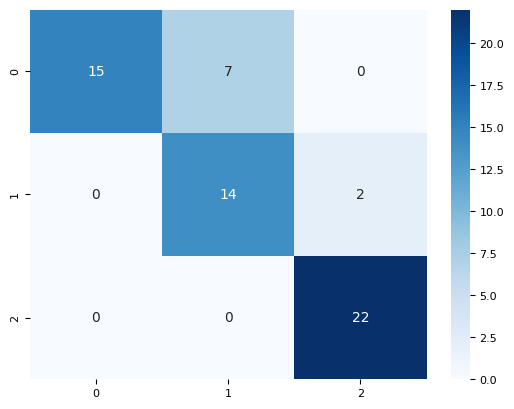

In [12]:
X = unitpop
y = stimtarget
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer et entraîner le modèle KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred = knn.predict(X_test)

# Évaluer la performance du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

### Évaluation Robuste KNN : 30 Itérations + Contrôle Hasard

**Objectif**
Tester la stabilité du classificateur **KNN (K=17)** sur 30 splits différents et valider la performance par rapport à un niveau de chance théorique.

#### ***Méthodologie***

#### 1. Validation Normale (30 itérations)
On évalue la capacité du modèle à généraliser sur des données réelles.
*   **Variables** : `X = unitpop`, `y = stimtarget`
*   **Processus** :
    ```python
    for i in range(30):
        # Split (80/20) avec seed variable pour la robustesse
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
        
        knn = KNeighborsClassifier(n_neighbors=17)
        knn.fit(X_train, y_train)
        
        # Stockage des scores et cumul de la matrice de confusion (3x3)
        accuracyall[i] = knn.score(X_test, y_test)
        CM += confusion_matrix(y_test, knn.predict(X_test))
    ```

#### 2. Contrôle Shuffle (30 itérations)
On casse la relation entre données et étiquettes pour établir la ligne de base du hasard.
*   **Processus** : Même boucle, mais avec `y_shuffled = np.random.permutation(y)`.
*   **Attendu** : `accuracyAllshuff` autour de **~33%** (puisqu'il y a 3 classes).

#### ***Visualisation***
Le script génère une figure de **1×2 (8×4)** pour synthétiser les résultats :

1.  **Gauche (Heatmap)** : Matrice de confusion normalisée en % pour les classes "Digit 2", "3" et "4".
2.  **Droite (Histogrammes)** : Comparaison des distributions :
    *   🔵 **Bleu** : Accuracy Originale.
    *   🟠 **Orange** : Accuracy Shuffled (Contrôle).
    *   ➖ **Ligne noire** : Seuil à 0.33 (niveau hasard).

#### ***Résultats Attendus***
*   **Mean Accuracy** : `0.XX` (Performance réelle moyenne)
*   **Mean Accuracy Shuffled** : `0.33` (Validation du contrôle)

> **Conclusion** : Si l'Accuracy est significativement supérieure à **0.33**, on valide un **décodage significatif** des conditions D2/D3/D4 par le classificateur.

Mean Accuracy:  0.9427777777777776
Mean Accuracy Shuffled:  0.3066666666666667


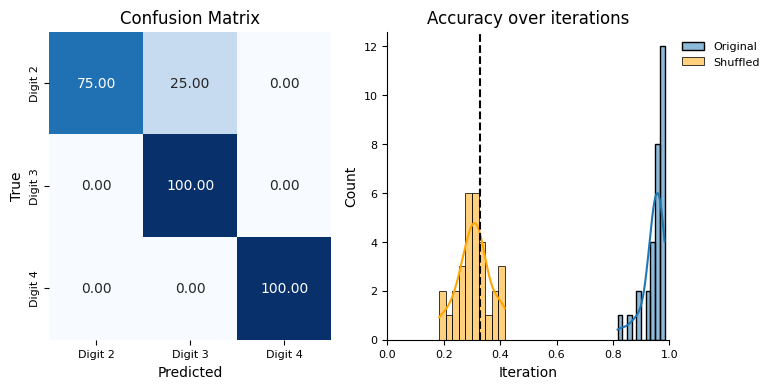

In [13]:
X = unitpop
y = stimtarget
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CM=np.zeros((3,3)) # matrice de confusion pour les 3 classes
accuracyall=[]

for i in range(30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i) # je change le random state pour faire 30 itérations différentes
    accuracy=[]

    # Créer et entraîner le modèle KNN
    knn = KNeighborsClassifier(n_neighbors=17)
    knn.fit(X_train, y_train)

    # Faire des prédictions sur l'ensemble de test
    y_pred = knn.predict(X_test)

    accuracyall.append(accuracy_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    CM+=cm

accuracyAllshuff=[]
for i in range(30):
    # Diviser les données en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(X, np.random.permutation(y), test_size=0.2, random_state=i)
    accuracy = []
    # Créer et entraîner le modèle KNN
    knn = KNeighborsClassifier(n_neighbors=17)
    knn.fit(X_train, y_train)

    # Faire des prédictions sur l'ensemble de test
    y_pred = knn.predict(X_test)

    # Évaluer la performance du modèle
    accuracyAllshuff.append(accuracy_score(y_test, y_pred))

print("Mean Accuracy: ", np.mean(accuracyall))
print("Mean Accuracy Shuffled: ", np.mean(accuracyAllshuff))

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8,4),nrows=1,ncols=2)
sns.heatmap(cm_normalized*100, annot=True, fmt='.2f',cmap='Blues',
            xticklabels=['Digit 2', 'Digit 3', 'Digit 4'],
            yticklabels=['Digit 2', 'Digit 3', 'Digit 4'],
            cbar=False, ax=ax[0])

ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')
ax[0].set_title('Confusion Matrix')
sns.histplot(accuracyall, ax=ax[1], bins=10, kde=True, label='Original')
sns.histplot(accuracyAllshuff, ax=ax[1], bins=10, kde=True, color='orange', label='Shuffled')
ax[1].legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax[1].set_title('Accuracy over iterations')
ax[1].set_xlabel('Iteration')
ax[1].set_xlim(0, 1)
ax[1].axvline(x=0.33, color='k', linestyle='--', label='Chance Level')
plt.show()

un autre k et on fait un append de k dans une liste, et on fait un plot de la précision en fonction du k.
On fait une boucle, pour que le n neightbourf il change à chaque fois, et on regarde la précision à chaque fois, et on fait un plot de la précision en fonction du n neighbor.



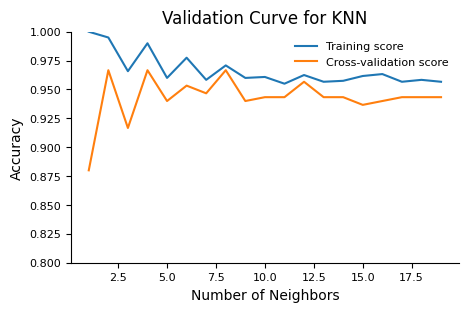

In [14]:

# Définir le modèle et le paramètre à valider
model = KNeighborsClassifier()
param_name = 'n_neighbors'
param_range = np.arange(1, 20)

# Calculer la courbe de validation
train_scores, test_scores = validation_curve(
    model, X, y, param_name=param_name, param_range=param_range, cv=5, scoring='accuracy'
)

# Tracer la courbe de validation
plt.figure(figsize=(5, 3))
plt.plot(param_range, np.mean(train_scores, axis=1), label='Training score')
plt.plot(param_range, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('Validation Curve for KNN')
plt.ylim(0.8, 1.0)
plt.legend()
plt.show()

Accuracy: 0.93


Text(12.222222222222223, 0.5, 'True')

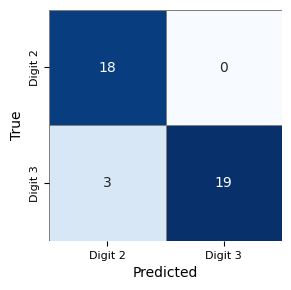

In [15]:
## MLP for N neurons and 2 classes
### using sklearn Perceptron

X=unitpop[0:200,:] # use all neurons as features

y=stimtarget[0:200] # to have labels 0,1,2,3 instead of 2,3,4,5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create and train the Perceptron model
perceptron = Perceptron(random_state=15, max_iter=5000) # increase max_iter if not converged
perceptron.fit(X_train, y_train)

# Make predictions on the test set
y_pred = perceptron.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,linewidths=0.5, linecolor='gray',xticklabels=['Digit 2', 'Digit 3'], yticklabels=['Digit 2', 'Digit 3'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

On peut utilise un perceptron qu'on a vu en cours, mais on peut utiliser celui de skit-learn. Un seul neurones ne peut accepter que 1 et 0 sauf que la on a 3 neurones donc on prends que les 200 prémiere ligne qui corresponds que au D2 et D3 
max_iter 5000

On va faire des liste de model, et on compare les listes des accuracy 

Prendre le truc sur git hub, pour tester les co stim de D2 et D4 avec un MLP, un KNN 
La mission de mtn, c'est si on prend perceptrion D2 D3

Dense = tous les neurones de la couche vont aller projeter sur les neurones de la couche suivant (tous)
- On lui met le n neurones et le nombre d'entrée

La fonction d'activation, c'est le fait que les neurones recoit les entrée et fait une moyenne pondérer, elle peut prendre la forme d'une sigmoide ect.. mais celle qui sont les plus utiliser c'est les rectification unit. 

Donc on def une couche avec 900 neurones (ex), eux recoivent l'infos, et il vont aller vers une 2eme couche que on doit def aussi (dense(32, activation= 'relu')). 
Ensuite on prend une autre couche, qui est une couche de sortit, ce quei correspond à 3 neurones ce qui correspond a nos 3 doigts 

- solt max -> la on utiliser ça, parce que on 3 focntion. Il va générer 3 probabilité, et il prends celle quie est la plus haute 

Ensuite on compile le model, 'dessente de gradient 'adam' et la loss fonction sparse catefoa

Et apres on fait un model fit (epoch et batch_size (petit echantillon ))
Donc on peut faire un réseau de neurones en 6 lignes 

In [16]:
X= unitpop[:,:100]
y= stimtarget

accscore_MLP=[]
layers=[2, 4, 8, 16, 32, 64, 128, 256]

model = Sequential()

for d in layers:
    CM_NN=np.zeros((3,3))
    split= 0
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,test_size=0.2, random_state=split)

    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(11, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # Keras expects array-like labels and class indices starting at 0 for sparse_categorical_crossentropy
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int32) - 2   # 2,3,4 -> 0,1,2
    y_test = np.asarray(y_test, dtype=np.int32) - 2

    model.fit(X_train, y_train, epochs=10, verbose=1, batch_size=64)

    history = model.history.history
    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    accscore_MLP.append(accuracy_score(y_test, y_pred))

    loss, accuracy = model.evaluate(X_test, y_test, verbose=1) #verbse=1 pour afficher la progression de l'évaluation
    accuracy = accuracy * 100
    print(f'Test accuracy: {accuracy:.2f}%')
    print(f'loss: {loss:.4f}')

    cm=confusion_matrix(y_test, y_pred)
    CM_NN += cm

model.summary()

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3458 - loss: 1.0906
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4167 - loss: 1.0333
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4708 - loss: 0.9867
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5292 - loss: 0.9380 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5583 - loss: 0.8822
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6167 - loss: 0.8261 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6333 - loss: 0.7718
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6375 - loss: 0.7253 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6500 - loss: 0.6830
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6500 - loss: 0.6455
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5833 - loss: 0.7466 
Test accuracy: 58.33%
loss: 0.7466
Epoch 1/10
4/4 ━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 11)             │         1,419 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,458 (329.92 KB)

 Trainable params: 28,152 (109.97 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,306 (219.95 KB)

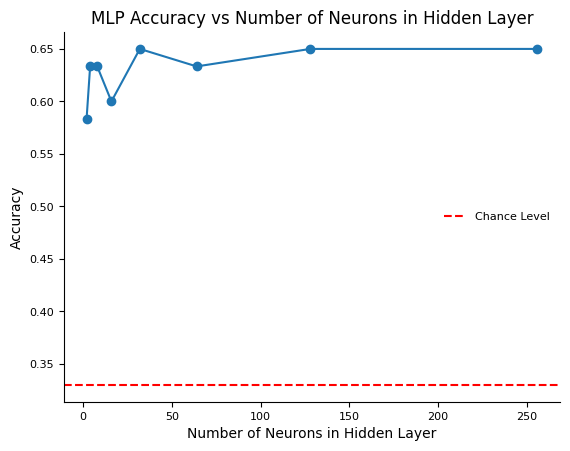

In [17]:
#En fonction du nombre de neurones dans la couche cachée, on peut faire un plot de la précision en fonction du nombre de neurones dans la couche cachée.
plt.plot(layers, accscore_MLP, marker='o')

plt.xlabel('Number of Neurons in Hidden Layer')
plt.ylabel('Accuracy')
plt.title('MLP Accuracy vs Number of Neurons in Hidden Layer')
plt.axhline(y=0.33, color='r', linestyle='--', label='Chance Level')
plt.legend()
plt.show()
